In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import os
import itertools
import joblib

from sklearn.preprocessing import MinMaxScaler
import keras
from keras.models import Model
from keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Dropout, Conv1D, BatchNormalization, MaxPooling1D, UpSampling1D
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from pathlib import Path
import seaborn as sns
from sklearn.metrics import auc

2025-06-16 11:18:14.751491: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
def extract_sd_per_location(data):
    """
    Extract standard deviation per location across all samples and timesteps
    
    Parameters:
    data: numpy array of shape (samples, locations, timesteps)
    
    Returns:
    sd_values: numpy array of shape (locations,) containing SD for each location
    """
    
    reshaped_data = data.transpose(1, 0, 2).reshape(data.shape[1], -1)  # (569, 1388*59)
    sd_values = np.std(reshaped_data, axis=1) 
    
    return sd_values

In [ ]:
def plot_sd_ascending(sd_values, sort_data=False):
    """
    Plot SD values with transformed location IDs as string labels on x-axis
    
    Parameters:
    sd_values: numpy array of SD values per location
    sort_data: boolean, if True sorts by SD values, if False keeps original order
    """

    location_ids = np.arange(len(sd_values)) * 10 + 1260

    if sort_data:
        sort_idx = np.argsort(sd_values)
        plotted_sd = sd_values[sort_idx]
        plotted_locations = location_ids[sort_idx]
    else:
        plotted_sd = sd_values
        plotted_locations = location_ids

    x_positions = range(len(plotted_sd))
    location_labels = [str(loc) for loc in plotted_locations]

    plt.figure(figsize=(16, 6))
    plt.scatter(x_positions, plotted_sd, c='red', s=10, alpha=0.6)
    plt.xticks(x_positions, location_labels, rotation=90, fontsize=3, ha='center')
    plt.xlabel('Location ID')
    plt.ylabel('Standard Deviation')
    plt.title("Standard Deviation per Location")
    plt.grid(True, alpha=0.3)

    plt.text(0.02, 0.98, f'Min SD: {np.min(plotted_sd):.4f}\nMax SD: {np.max(plotted_sd):.4f}\nMean SD: {np.mean(plotted_sd):.4f}', 
             transform=plt.gca().transAxes, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

    return plotted_sd, plotted_locations


In [4]:
TRAIN_FILEPATH = 'data_for_model/sound_levels_data.npy'

In [5]:
data = np.load(TRAIN_FILEPATH)

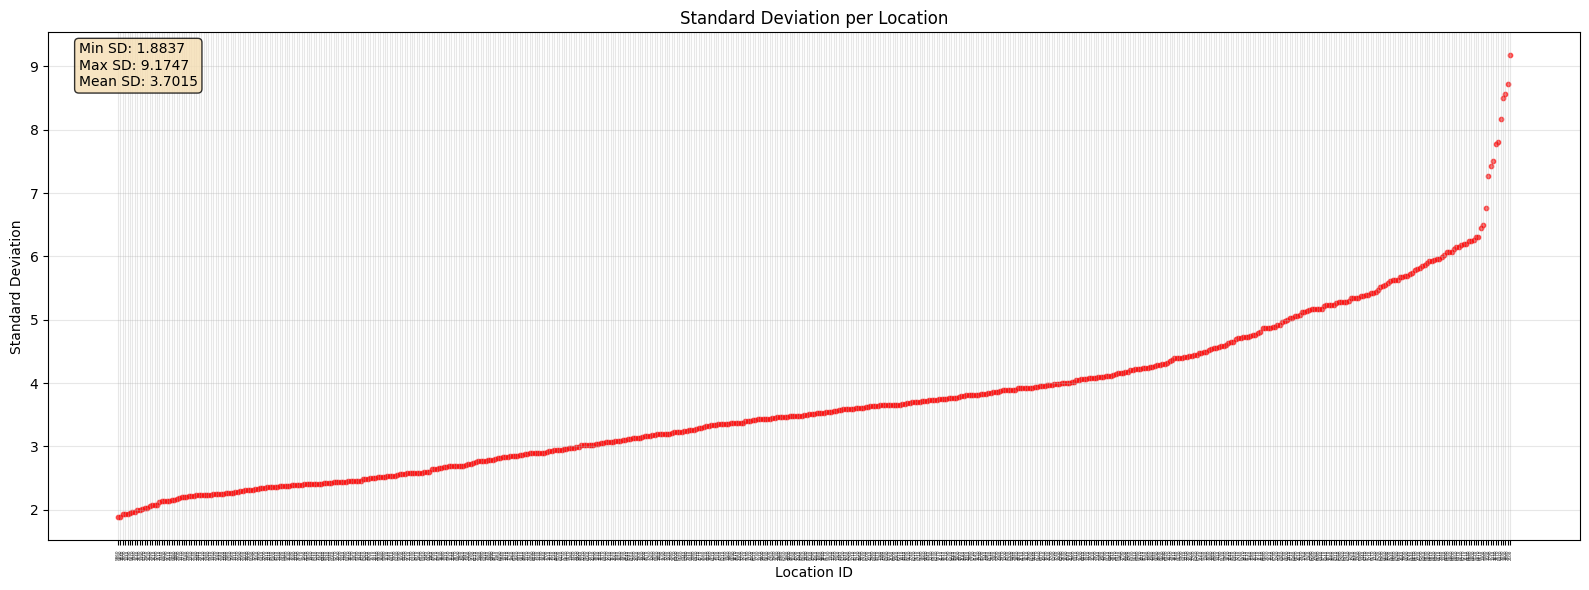

In [19]:
sd_s = extract_sd_per_location(data)
plotted_sd, transformed_location_ids = plot_sd_ascending(sd_s, sort_data=True)

In [ ]:
n = len(transformed_location_ids)
middle_start = n // 2 - 2

bottom_5_locs = transformed_location_ids[:5]
bottom_5_sds = plotted_sd[:5]

top_5_locs = transformed_location_ids[-5:]
top_5_sds = plotted_sd[-5:]

middle_5_locs = transformed_location_ids[middle_start:middle_start+5]
middle_5_sds = plotted_sd[middle_start:middle_start+5]

print("Bottom 5 (lowest SD):")
for loc, sd in zip(bottom_5_locs, bottom_5_sds):
   print(f"  Location {loc}: SD = {sd:.6f}")

print("\nTop 5 (highest SD):")
for loc, sd in zip(top_5_locs, top_5_sds):
   print(f"  Location {loc}: SD = {sd:.6f}")

print("\nMiddle 5:")
for loc, sd in zip(middle_5_locs, middle_5_sds):
   print(f"  Location {loc}: SD = {sd:.6f}")

Bottom 5 (lowest SD):
  Location 5860: SD = 1.883707
  Location 5890: SD = 1.884679
  Location 3540: SD = 1.926545
  Location 2600: SD = 1.931489
  Location 1430: SD = 1.934016

Top 5 (highest SD):
  Location 6370: SD = 8.178250
  Location 3090: SD = 8.509840
  Location 3800: SD = 8.566730
  Location 2680: SD = 8.722322
  Location 2100: SD = 9.174695

Middle 5:
  Location 4350: SD = 3.514658
  Location 5540: SD = 3.516967
  Location 4290: SD = 3.518180
  Location 4450: SD = 3.522967
  Location 1680: SD = 3.525256
